# (07) Animate recon mp4: Kyoto

host = ```mach```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## anim setup

In [3]:
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/true_and_recon')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[
    'kyoto_translate_crop32.mp4',
    'kyoto_translate_speed-uniform-0.5.mp4',
    'mnist-to-emnist_rotate-4.mp4',
    'mnist-to-emnist_rotate-uniform4.mp4',
    'mnist-to-omni_rotate-4.mp4',
    'mnist-to-omni_rotate-uniform4.mp4',
    'mnist_rotate-4.mp4'
]

## Test a Kyoto model

`K = 256`

### list of fits

In [4]:
from analysis.final import perform_analysis, get_root_path

root = get_root_path()

patterns = [
    'Kyoto-wht+translate_t-(16,8,4)',
    'b-2_kms-(256,8,3)',
    # 'speed-sample-uniform',
]
fits = [
    f for f in sorted(os.listdir(root), key=alphanum_sort_key)
    if all(p in f for p in patterns)
]
print(fits)

['poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(256,8,3)_recon-mse_mach-0_(2025_09_06,12:40)']

### load Kyoto model

In [5]:
fit = 'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(256,8,3)_recon-mse_mach-0_(2025_09_06,12:40)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

300

### sanity check

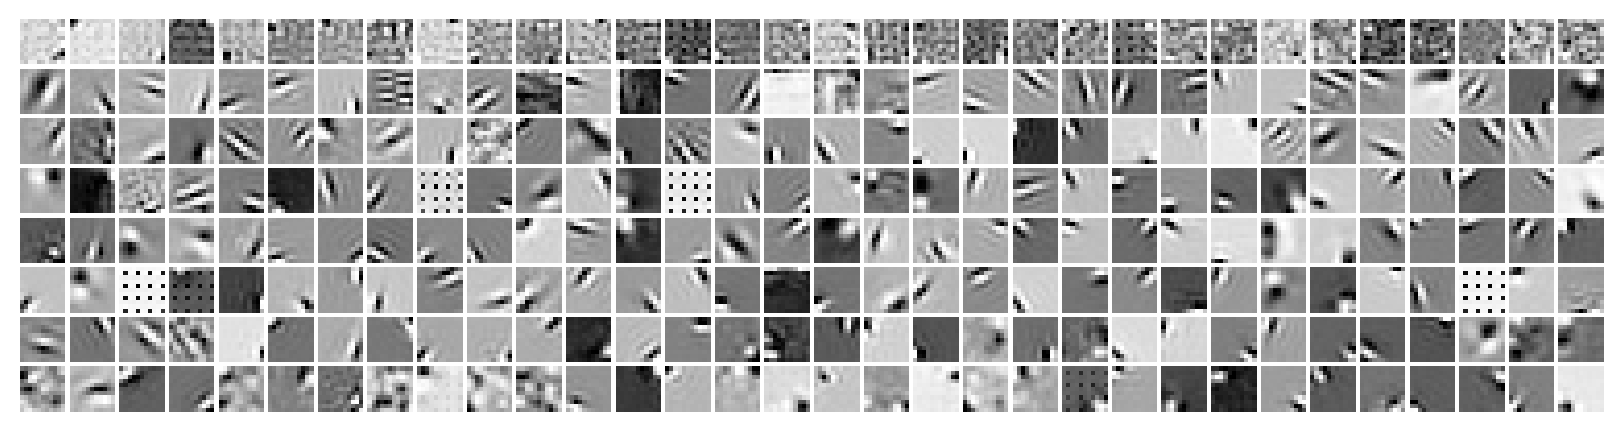

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████| 100/100 [05:35<00:00,  3.36s/it]


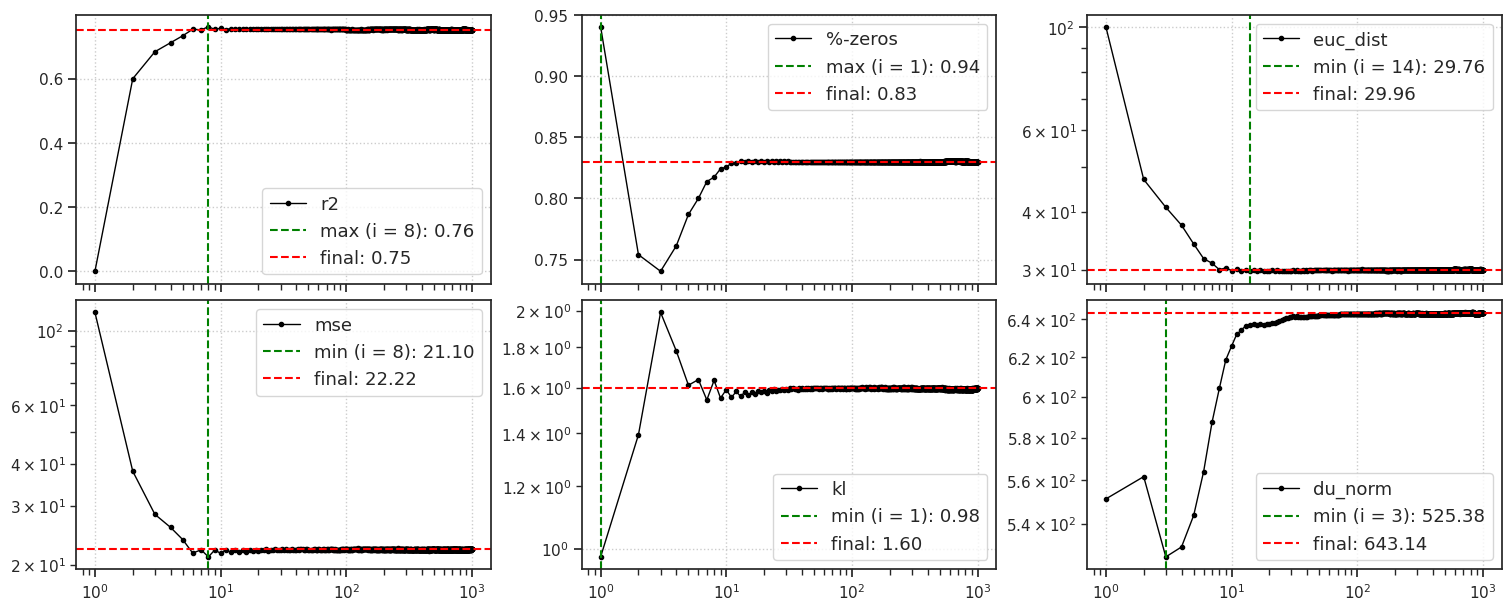

CPU times: user 5min 36s, sys: 1.15 s, total: 5min 37s
Wall time: 5min 37s


In [7]:
%%time

results = tr.analysis(t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='k')

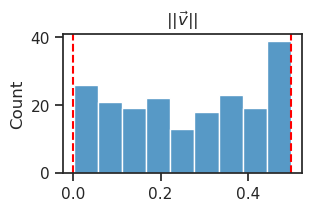

In [8]:
speeds = tr.feeder_vld.apply_anneal(-1)

fig, ax = create_figure()
sns.histplot(tonp(speeds), ax=ax)
ax.axvline(0, color='r', ls='--')
ax.axvline(tr.feeder_vld.max_speed, color='r', ls='--')
ax.set_title(r"$\vert\vert \vec{v} \vert\vert$")
plt.show()

### xtract kyoto ftrs

In [9]:
%%time


output = tr.xtract_ftr(
    data='vld',
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 4.94 s, sys: 3.01 s, total: 7.95 s
Wall time: 7.95 s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

### save animation mp4

In [10]:
rng = get_rng(0)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)
sample_ids

array([45,  0, 28, 34, 17, 10, 15,  2, 40, 50, 58,  4])

CPU times: user 4min 56s, sys: 8.12 s, total: 5min 4s
Wall time: 5min 38s


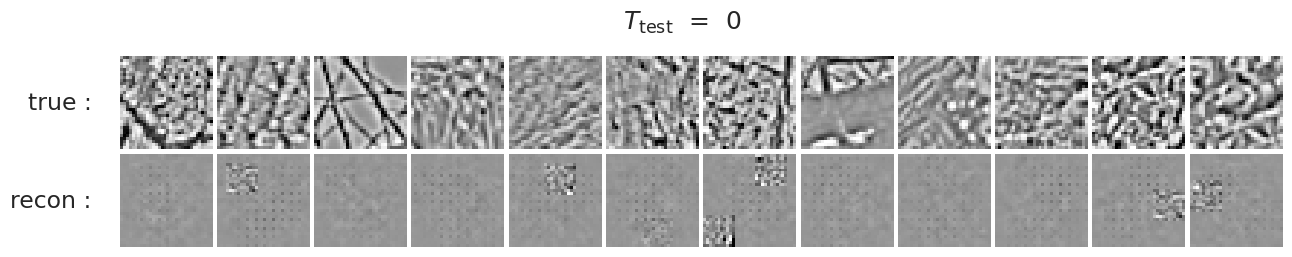

In [11]:
%%time


file_name = 'kyoto_translate_speed-uniform-0.5'

_ = animate_recons(
    save_file=pjoin(anim_dir, f"{file_name}.mp4"),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    symmetric_vrange=True,
    # dry_run=True,
)

## Test another Kyoto model

`K = 512`

In [4]:
from analysis.final import perform_analysis, get_root_path

root = get_root_path()
patterns = [
    'Kyoto-wht+translate_t-(16,8,4)',
    'b-2_kms-(512,8,3)',
    'max-speed=2.0',
]
fits = [
    f for f in sorted(os.listdir(root), key=alphanum_sort_key)
    if all(p in f for p in patterns)
]
print(fits)

[
    'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,8,3)_recon-mse_speed-sample-uniform_max-speed=2.
0_mach-0_(2025_09_08,00:17)',
    'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,8,3)_recon-mse_speed-sample-uniform_max-speed=2.
0_mach-0_(2025_09_08,00:20)'
]

### load Kyoto model

In [5]:
fit = 'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,8,3)_recon-mse_speed-sample-uniform_max-speed=2.0_mach-0_(2025_09_08,00:17)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

300

### sanity check

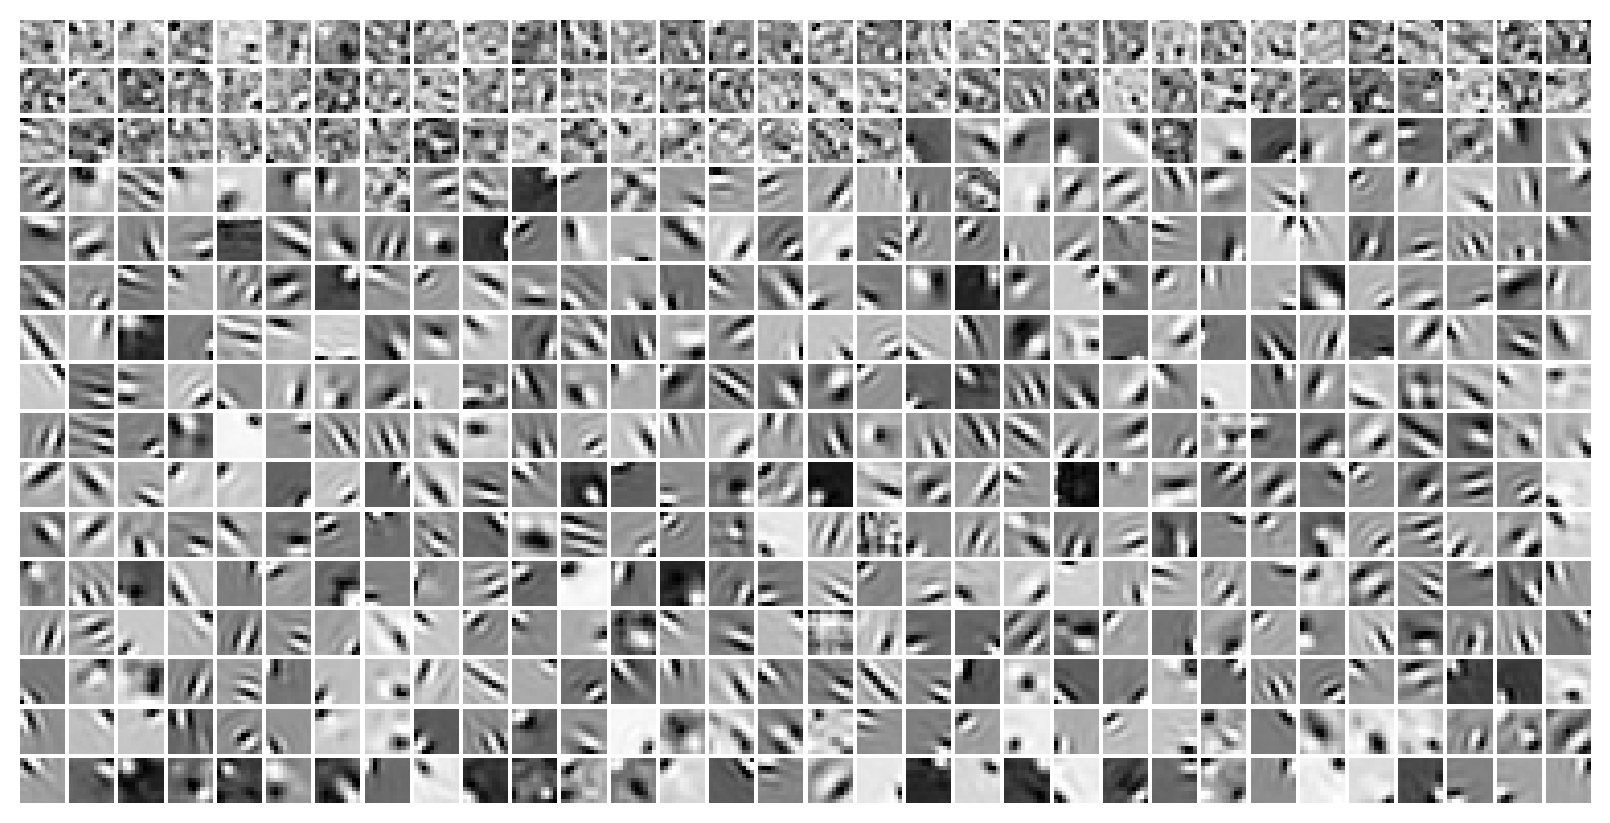

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████| 100/100 [05:13<00:00,  3.14s/it]


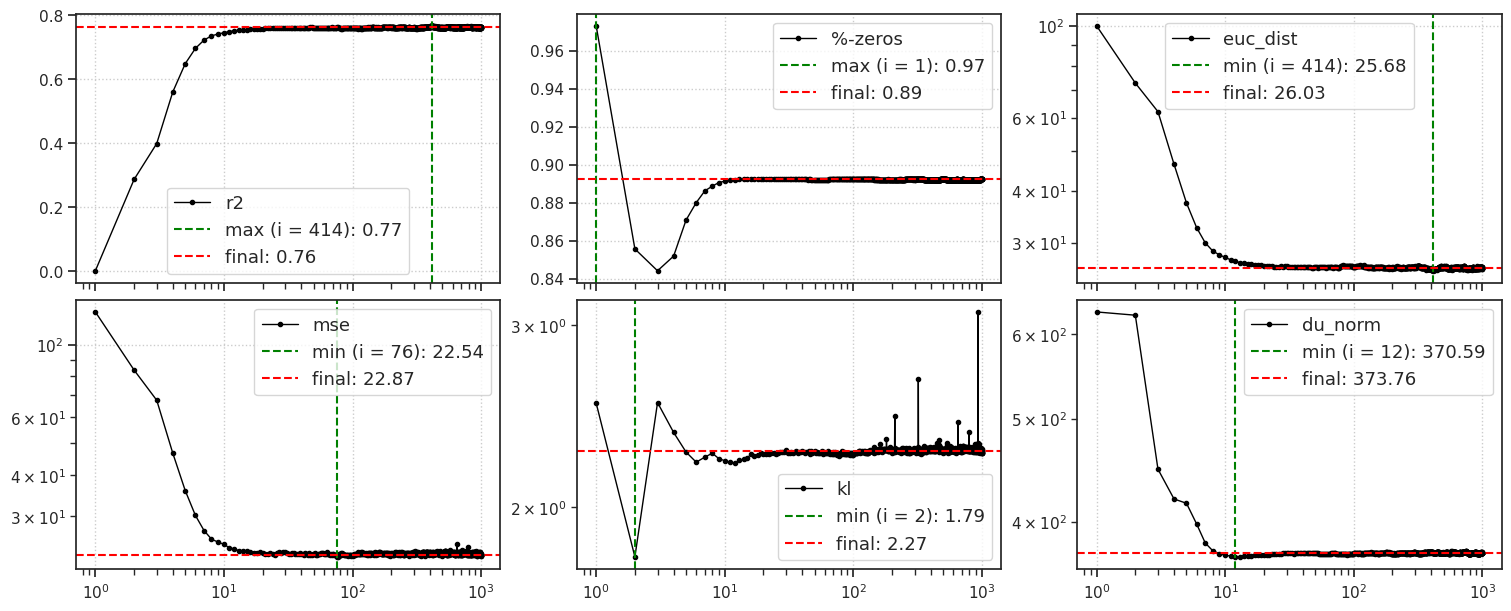

CPU times: user 5min 14s, sys: 1.19 s, total: 5min 15s
Wall time: 5min 15s


In [7]:
%%time

results = tr.analysis(t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='k')

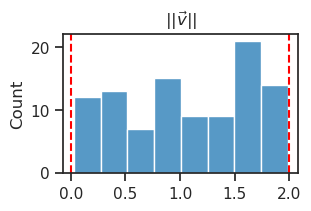

In [8]:
speeds = tr.feeder_vld.apply_anneal(-1)

fig, ax = create_figure()
sns.histplot(tonp(speeds), ax=ax)
ax.axvline(0, color='r', ls='--')
ax.axvline(tr.feeder_vld.max_speed, color='r', ls='--')
ax.set_title(r"$\vert\vert \vec{v} \vert\vert$")
plt.show()

### xtract kyoto ftrs

In [9]:
%%time


output = tr.xtract_ftr(
    data='vld',
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 7.07 s, sys: 5.78 s, total: 12.8 s
Wall time: 12.8 s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

### save animation mp4

In [10]:
rng = get_rng(0)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)
sample_ids

array([45,  0, 28, 34, 17, 10, 15,  2, 40, 50, 58,  4])

CPU times: user 5min 7s, sys: 11 s, total: 5min 18s
Wall time: 5min 55s


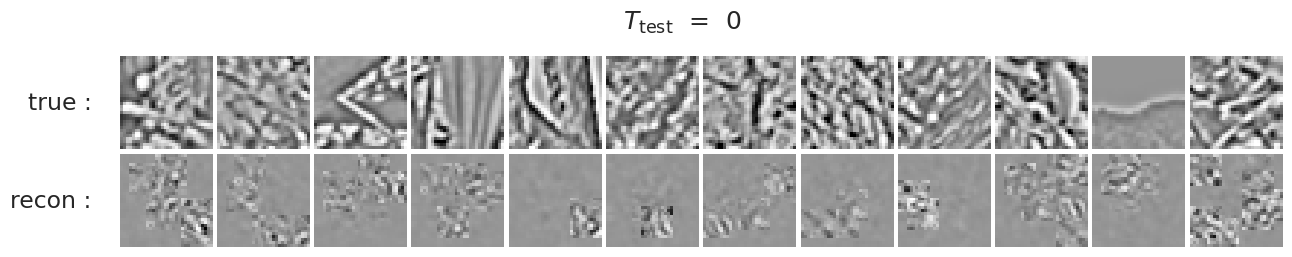

In [20]:
%%time


file_name = '_'.join([
    tr.model.cfg.dataset,
    tr.model.cfg.str_kms,
    tr.model.cfg.str_fwd,
    f"speed-{tr.model.cfg.feeder_cfg['max_speed']}"
])

_ = animate_recons(
    save_file=pjoin(anim_dir, f"{file_name}.mp4"),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    symmetric_vrange=True,
    # dry_run=True,
)